In [ ]:
import os
import glob
import re
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

VALID_LABELS = ["hate", "hope", "not_applicable"]

RESULTS_DIR = "/content/"
OUTPUT_DIR = os.path.join(RESULTS_DIR, "comparison_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
def infer_prompt_name_from_path(path):
    name = os.path.basename(path)
    name = name.replace(".csv", "")

    # handle examples:
    # metrics_summary_zero.csv
    # metrics_per_class_few.csv
    # results_zero_shot_definition_gemini_2_5_flash.csv

    if name.startswith("metrics_summary"):
        return name.replace("metrics_summary", "")

    if name.startswith("metrics_per_class_"):
        return name.replace("metrics_per_class_", "")

    if name.startswith("results_"):
        x = name.replace("results_", "")
        x = x.replace("_gemini_2_5_flash", "")
        x = x.replace("_gemini_3_flash_preview", "")
        return x

    return name


def load_all_prompt_files(results_dir):
    summary_files = sorted(glob.glob(os.path.join(results_dir, "metrics_summary*.csv")))
    per_class_files = sorted(glob.glob(os.path.join(results_dir, "metrics_per_class*.csv")))
    result_files = sorted(glob.glob(os.path.join(results_dir, "results_*.csv")))

    summary_frames = []
    per_class_frames = []
    result_frames = []

    for path in summary_files:
        df = pd.read_csv(path)
        if "prompt_short" not in df.columns:
            df["prompt_short"] = infer_prompt_name_from_path(path)
        summary_frames.append(df)

    for path in per_class_files:
        df = pd.read_csv(path)
        if "prompt_short" not in df.columns:
            df["prompt_short"] = infer_prompt_name_from_path(path)
        per_class_frames.append(df)

    for path in result_files:
        df = pd.read_csv(path)
        if "prompt_short" not in df.columns:
            df["prompt_short"] = infer_prompt_name_from_path(path)
        result_frames.append(df)

    summary_all = pd.concat(summary_frames, ignore_index=True) if summary_frames else pd.DataFrame()
    per_class_all = pd.concat(per_class_frames, ignore_index=True) if per_class_frames else pd.DataFrame()
    results_all = pd.concat(result_frames, ignore_index=True) if result_frames else pd.DataFrame()

    return summary_all, per_class_all, results_all


summary_all, per_class_all, results_all = load_all_prompt_files(RESULTS_DIR)

print("Summary files merged:", summary_all.shape)
print("Per-class files merged:", per_class_all.shape)
print("Row-level result files merged:", results_all.shape)

display(summary_all)
display(per_class_all)
display(results_all.head())

Summary files merged: (5, 18)
Per-class files merged: (15, 7)
Row-level result files merged: (2500, 12)


,prompt_type,model,total_samples,processed_samples,valid_predictions,invalid_predictions,invalid_rate_processed,accuracy,precision_macro,recall_macro,f1_macro,precision_micro,recall_micro,f1_micro,precision_weighted,recall_weighted,f1_weighted,prompt_short
0,few_shot_definition,gemini-3-flash-preview,500,500,500,0,0.0,0.654000,0.638285,0.704031,0.654318,0.654000,0.654000,0.654000,0.678973,0.654000,0.653488,_few
1,three_shot_cultural,gemini-3-flash-preview,500,375,375,0,0.0,0.674667,0.658205,0.717943,0.673151,0.674667,0.674667,0.674667,0.698748,0.674667,0.675141,_few_cultural
2,zero_shot_nli,gemini-3-flash-preview,500,370,370,0,0.0,0.654054,0.641865,0.707897,0.655559,0.654054,0.654054,0.654054,0.683578,0.654054,0.653208,_nli
3,zero_shot_definition,gemini-3-flash-preview,500,500,500,0,0.0,0.634000,0.622053,0.694388,0.636447,0.634000,0.634000,0.634000,0.666075,0.634000,0.632365,_zero
4,zero_shot_distinction,gemini-3-flash-preview,500,500,500,0,0.0,0.682000,0.692932,0.607431,0.630954,0.682000,0.682000,0.682000,0.686198,0.682000,0.672180,_zero_distinction


,prompt_type,label,precision,recall,f1,support,prompt_short
0,few_shot_definition,hate,0.542254,0.875000,0.669565,88.0,few
1,few_shot_definition,hope,0.619048,0.654676,0.636364,139.0,few
2,few_shot_definition,not_applicable,0.753555,0.582418,0.657025,273.0,few
3,three_shot_cultural,hate,0.552381,0.865672,0.674419,67.0,few_cultural
4,three_shot_cultural,hope,0.648649,0.679245,0.663594,106.0,few_cultural
5,three_shot_cultural,not_applicable,0.773585,0.608911,0.681440,202.0,few_cultural
6,zero_shot_nli,hate,0.532110,0.878788,0.662857,66.0,nli
7,zero_shot_nli,hope,0.631579,0.679245,0.654545,106.0,nli
8,zero_shot_nli,not_applicable,0.761905,0.565657,0.649275,198.0,nli
9,zero_shot_definition,hate,0.520000,0.886364,0.655462,88.0,zero


,sample_id,text,label,prompt_type,model,pred,raw_output,processed,correct,batch_id,timestamp,prompt_short
0,0,ممكن مبادل نحيف مره لاربعيني رجولي #مبادل_الطا...,not_applicable,few_shot_definition,gemini-3-flash-preview,not_applicable,1: not_applicable\n2: not_applicable\n3: hate\...,True,1.0,few_shot_definition_batch_0000,2026-05-04T21:30:51.031875,few_shot_definition
1,1,لَا أَسْتَطِيعُ أَنْ أُبْذِلَ الْجُرْأَةَ لِأُ...,hate,few_shot_definition,gemini-3-flash-preview,not_applicable,1: not_applicable\n2: not_applicable\n3: hate\...,True,0.0,few_shot_definition_batch_0000,2026-05-04T21:30:51.031875,few_shot_definition
2,2,دولة جزر القمر تقوم بخطوات سريعة وقرارات سليمة...,not_applicable,few_shot_definition,gemini-3-flash-preview,hate,1: not_applicable\n2: not_applicable\n3: hate\...,True,0.0,few_shot_definition_batch_0000,2026-05-04T21:30:51.031875,few_shot_definition
3,3,: اللهم اصلح شان اخواننا المسلمين اهل السنه في...,hope,few_shot_definition,gemini-3-flash-preview,hope,1: not_applicable\n2: not_applicable\n3: hate\...,True,1.0,few_shot_definition_batch_0000,2026-05-04T21:30:51.031875,few_shot_definition
4,4,. أَشْعُرُ بِالْفَخْرِ لِحُصُولِي عَلَى هَذِهِ...,hope,few_shot_definition,gemini-3-flash-preview,hope,1: not_applicable\n2: not_applicable\n3: hate\...,True,1.0,few_shot_definition_batch_0000,2026-05-04T21:30:51.031875,few_shot_definition


In [ ]:
def normalize_label(x):
    x = str(x).strip().lower()
    x = x.replace(" ", "").replace("\n", "").replace("\t", "")

    mapping = {
        "hate": "hate",
        "hope": "hope",
        "not_applicable": "not_applicable",
        "notapplicable": "not_applicable",
        "not-applicable": "not_applicable",
        "invalid": "INVALID",
        "error": "ERROR",
        "nan": "INVALID",
        "": "INVALID"
    }

    return mapping.get(x, x)


def standardize_results_df(df):
    df = df.copy()

    if "gold" not in df.columns:
        if "label" in df.columns:
            df["gold"] = df["label"]
        else:
            raise ValueError("No gold or label column found.")

    df["gold"] = df["gold"].astype(str).str.strip().str.lower()
    df["pred"] = df["pred"].apply(normalize_label)

    if "processed" in df.columns:
        df["processed_bool"] = df["processed"].astype(str).str.lower().isin(["true", "1", "yes"])
    else:
        df["processed_bool"] = True

    df["is_valid_gold"] = df["gold"].isin(VALID_LABELS)
    df["is_valid_pred"] = df["pred"].isin(VALID_LABELS)
    df["is_valid_eval"] = df["processed_bool"] & df["is_valid_gold"] & df["is_valid_pred"]
    df["correct_eval"] = (df["gold"] == df["pred"]).astype(int)

    return df


results_all = standardize_results_df(results_all)
display(results_all.head())

,sample_id,text,label,prompt_type,model,pred,raw_output,processed,correct,batch_id,timestamp,prompt_short,gold,processed_bool,is_valid_gold,is_valid_pred,is_valid_eval,correct_eval
0,0,ممكن مبادل نحيف مره لاربعيني رجولي #مبادل_الطا...,not_applicable,few_shot_definition,gemini-3-flash-preview,not_applicable,1: not_applicable\n2: not_applicable\n3: hate\...,True,1.0,few_shot_definition_batch_0000,2026-05-04T21:30:51.031875,few_shot_definition,not_applicable,True,True,True,True,1
1,1,لَا أَسْتَطِيعُ أَنْ أُبْذِلَ الْجُرْأَةَ لِأُ...,hate,few_shot_definition,gemini-3-flash-preview,not_applicable,1: not_applicable\n2: not_applicable\n3: hate\...,True,0.0,few_shot_definition_batch_0000,2026-05-04T21:30:51.031875,few_shot_definition,hate,True,True,True,True,0
2,2,دولة جزر القمر تقوم بخطوات سريعة وقرارات سليمة...,not_applicable,few_shot_definition,gemini-3-flash-preview,hate,1: not_applicable\n2: not_applicable\n3: hate\...,True,0.0,few_shot_definition_batch_0000,2026-05-04T21:30:51.031875,few_shot_definition,not_applicable,True,True,True,True,0
3,3,: اللهم اصلح شان اخواننا المسلمين اهل السنه في...,hope,few_shot_definition,gemini-3-flash-preview,hope,1: not_applicable\n2: not_applicable\n3: hate\...,True,1.0,few_shot_definition_batch_0000,2026-05-04T21:30:51.031875,few_shot_definition,hope,True,True,True,True,1
4,4,. أَشْعُرُ بِالْفَخْرِ لِحُصُولِي عَلَى هَذِهِ...,hope,few_shot_definition,gemini-3-flash-preview,hope,1: not_applicable\n2: not_applicable\n3: hate\...,True,1.0,few_shot_definition_batch_0000,2026-05-04T21:30:51.031875,few_shot_definition,hope,True,True,True,True,1


In [ ]:
def compute_metrics_from_rows(results_all):
    summary_rows = []
    per_class_rows = []

    for prompt_name, df_prompt in results_all.groupby("prompt_short"):
        processed_df = df_prompt[df_prompt["processed_bool"]].copy()
        valid_df = processed_df[processed_df["is_valid_eval"]].copy()

        if len(valid_df) == 0:
            continue

        y_true = valid_df["gold"].tolist()
        y_pred = valid_df["pred"].tolist()

        summary_rows.append({
            "prompt": prompt_name,
            "total_samples": len(df_prompt),
            "processed_samples": len(processed_df),
            "valid_predictions": len(valid_df),
            "invalid_predictions": int((~processed_df["is_valid_pred"]).sum()),
            "invalid_rate": float((~processed_df["is_valid_pred"]).mean()),
            "accuracy": accuracy_score(y_true, y_pred),
            "precision_macro": precision_score(y_true, y_pred, labels=VALID_LABELS, average="macro", zero_division=0),
            "recall_macro": recall_score(y_true, y_pred, labels=VALID_LABELS, average="macro", zero_division=0),
            "f1_macro": f1_score(y_true, y_pred, labels=VALID_LABELS, average="macro", zero_division=0),
            "precision_weighted": precision_score(y_true, y_pred, labels=VALID_LABELS, average="weighted", zero_division=0),
            "recall_weighted": recall_score(y_true, y_pred, labels=VALID_LABELS, average="weighted", zero_division=0),
            "f1_weighted": f1_score(y_true, y_pred, labels=VALID_LABELS, average="weighted", zero_division=0),
        })

        p, r, f1, support = precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=VALID_LABELS,
            zero_division=0
        )

        for i, label in enumerate(VALID_LABELS):
            per_class_rows.append({
                "prompt": prompt_name,
                "label": label,
                "precision": p[i],
                "recall": r[i],
                "f1": f1[i],
                "support": support[i]
            })

    summary_df = pd.DataFrame(summary_rows)
    per_class_df = pd.DataFrame(per_class_rows)

    return summary_df, per_class_df


summary_recomputed, per_class_recomputed = compute_metrics_from_rows(results_all)

display(summary_recomputed)
display(per_class_recomputed)

summary_recomputed.to_csv(os.path.join(OUTPUT_DIR, "merged_summary_metrics.csv"), index=False)
per_class_recomputed.to_csv(os.path.join(OUTPUT_DIR, "merged_per_class_metrics.csv"), index=False)

,prompt,total_samples,processed_samples,valid_predictions,invalid_predictions,invalid_rate,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,few_shot_definition,500,500,500,0,0.0,0.654000,0.638285,0.704031,0.654318,0.678973,0.654000,0.653488
1,three_shot_cultural,500,375,375,0,0.0,0.674667,0.658205,0.717943,0.673151,0.698748,0.674667,0.675141
2,zero_shot_definition,500,500,500,0,0.0,0.634000,0.622053,0.694388,0.636447,0.666075,0.634000,0.632365
3,zero_shot_distinction,500,500,500,0,0.0,0.682000,0.692932,0.607431,0.630954,0.686198,0.682000,0.672180
4,zero_shot_nli,500,370,370,0,0.0,0.654054,0.641865,0.707897,0.655559,0.683578,0.654054,0.653208


,prompt,label,precision,recall,f1,support
0,few_shot_definition,hate,0.542254,0.875000,0.669565,88
1,few_shot_definition,hope,0.619048,0.654676,0.636364,139
2,few_shot_definition,not_applicable,0.753555,0.582418,0.657025,273
3,three_shot_cultural,hate,0.552381,0.865672,0.674419,67
4,three_shot_cultural,hope,0.648649,0.679245,0.663594,106
5,three_shot_cultural,not_applicable,0.773585,0.608911,0.681440,202
6,zero_shot_definition,hate,0.520000,0.886364,0.655462,88
7,zero_shot_definition,hope,0.598684,0.654676,0.625430,139
8,zero_shot_definition,not_applicable,0.747475,0.542125,0.628450,273
9,zero_shot_distinction,hate,0.744681,0.397727,0.518519,88


In [ ]:
main_cols = [
    "prompt",
    "processed_samples",
    "valid_predictions",
    "invalid_rate",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "f1_weighted"
]

overall_table = summary_recomputed[main_cols].copy()

for col in [
    "invalid_rate",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "f1_weighted"
]:
    overall_table[col] = overall_table[col].round(4)

display(overall_table)

overall_table.to_csv(os.path.join(OUTPUT_DIR, "table_overall_prompt_comparison.csv"), index=False)
print(overall_table.to_latex(index=False))

,prompt,processed_samples,valid_predictions,invalid_rate,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,few_shot_definition,500,500,0.0,0.6540,0.6383,0.7040,0.6543,0.6535
1,three_shot_cultural,375,375,0.0,0.6747,0.6582,0.7179,0.6732,0.6751
2,zero_shot_definition,500,500,0.0,0.6340,0.6221,0.6944,0.6364,0.6324
3,zero_shot_distinction,500,500,0.0,0.6820,0.6929,0.6074,0.6310,0.6722
4,zero_shot_nli,370,370,0.0,0.6541,0.6419,0.7079,0.6556,0.6532


\begin{tabular}{lrrrrrrrr}
\toprule
prompt & processed_samples & valid_predictions & invalid_rate & accuracy & precision_macro & recall_macro & f1_macro & f1_weighted \\
\midrule
few_shot_definition & 500 & 500 & 0.000000 & 0.654000 & 0.638300 & 0.704000 & 0.654300 & 0.653500 \\
three_shot_cultural & 375 & 375 & 0.000000 & 0.674700 & 0.658200 & 0.717900 & 0.673200 & 0.675100 \\
zero_shot_definition & 500 & 500 & 0.000000 & 0.634000 & 0.622100 & 0.694400 & 0.636400 & 0.632400 \\
zero_shot_distinction & 500 & 500 & 0.000000 & 0.682000 & 0.692900 & 0.607400 & 0.631000 & 0.672200 \\
zero_shot_nli & 370 & 370 & 0.000000 & 0.654100 & 0.641900 & 0.707900 & 0.655600 & 0.653200 \\
\bottomrule
\end{tabular}



In [ ]:
per_class_table = per_class_recomputed.copy()

for col in ["precision", "recall", "f1"]:
    per_class_table[col] = per_class_table[col].round(4)

display(per_class_table)

per_class_table.to_csv(os.path.join(OUTPUT_DIR, "table_per_class_prompt_comparison.csv"), index=False)
print(per_class_table.to_latex(index=False))

,prompt,label,precision,recall,f1,support
0,few_shot_definition,hate,0.5423,0.8750,0.6696,88
1,few_shot_definition,hope,0.6190,0.6547,0.6364,139
2,few_shot_definition,not_applicable,0.7536,0.5824,0.6570,273
3,three_shot_cultural,hate,0.5524,0.8657,0.6744,67
4,three_shot_cultural,hope,0.6486,0.6792,0.6636,106
5,three_shot_cultural,not_applicable,0.7736,0.6089,0.6814,202
6,zero_shot_definition,hate,0.5200,0.8864,0.6555,88
7,zero_shot_definition,hope,0.5987,0.6547,0.6254,139
8,zero_shot_definition,not_applicable,0.7475,0.5421,0.6285,273
9,zero_shot_distinction,hate,0.7447,0.3977,0.5185,88


\begin{tabular}{llrrrr}
\toprule
prompt & label & precision & recall & f1 & support \\
\midrule
few_shot_definition & hate & 0.542300 & 0.875000 & 0.669600 & 88 \\
few_shot_definition & hope & 0.619000 & 0.654700 & 0.636400 & 139 \\
few_shot_definition & not_applicable & 0.753600 & 0.582400 & 0.657000 & 273 \\
three_shot_cultural & hate & 0.552400 & 0.865700 & 0.674400 & 67 \\
three_shot_cultural & hope & 0.648600 & 0.679200 & 0.663600 & 106 \\
three_shot_cultural & not_applicable & 0.773600 & 0.608900 & 0.681400 & 202 \\
zero_shot_definition & hate & 0.520000 & 0.886400 & 0.655500 & 88 \\
zero_shot_definition & hope & 0.598700 & 0.654700 & 0.625400 & 139 \\
zero_shot_definition & not_applicable & 0.747500 & 0.542100 & 0.628500 & 273 \\
zero_shot_distinction & hate & 0.744700 & 0.397700 & 0.518500 & 88 \\
zero_shot_distinction & hope & 0.646600 & 0.618700 & 0.632400 & 139 \\
zero_shot_distinction & not_applicable & 0.687500 & 0.805900 & 0.742000 & 273 \\
zero_shot_nli & hate & 0.532100

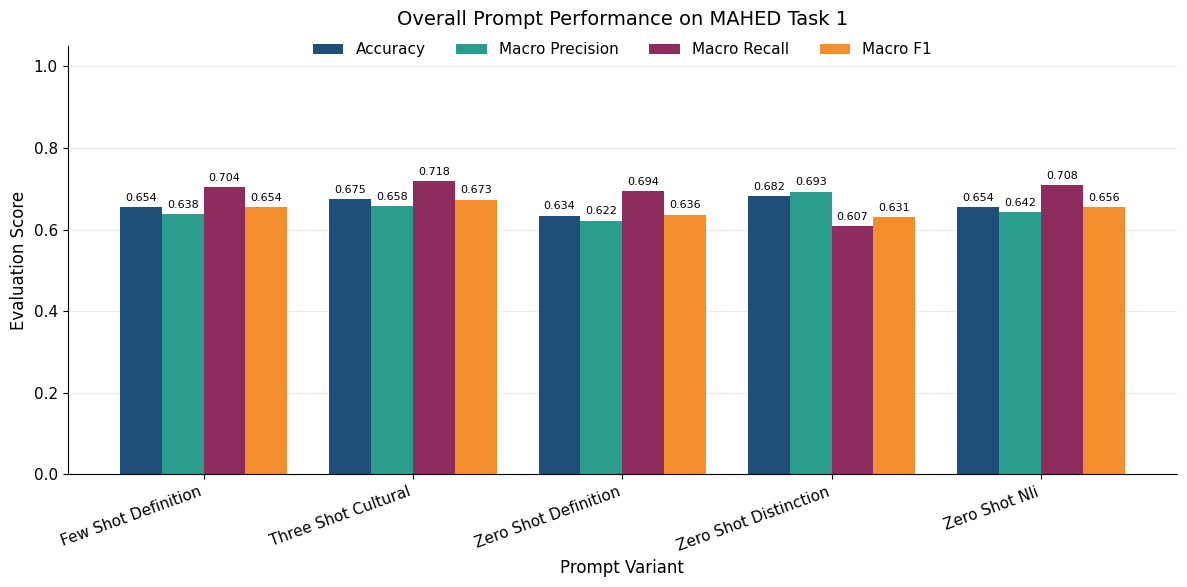

Saved: /content/comparison_outputs/fig_overall_prompt_comparison.png


In [ ]:
import os
import matplotlib.pyplot as plt

def plot_overall_metrics(summary_df):
    # Original metric columns
    metrics = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]

    # Cleaner display names for legend
    metric_labels = {
        "accuracy": "Accuracy",
        "precision_macro": "Macro Precision",
        "recall_macro": "Macro Recall",
        "f1_macro": "Macro F1"
    }

    # Palette inspired by your example image
    colors = ["#1f4e79", "#2a9d8f", "#8e2c5d", "#f28e2b"]

    # Set a clean professional font
    plt.rcParams["font.family"] = "DejaVu Sans"
    plt.rcParams["font.size"] = 11

    # Prepare dataframe
    plot_df = summary_df.set_index("prompt")[metrics].copy()
    plot_df = plot_df.rename(columns=metric_labels)

    # Optional: make prompt names cleaner too
    plot_df.index = plot_df.index.astype(str).str.replace("_", " ").str.title()

    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    plot_df.plot(kind="bar", ax=ax, color=colors, width=0.8)

    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=8, padding=3)

    # Titles and labels
    ax.set_title("Overall Prompt Performance on MAHED Task 1", fontsize=14, pad=15)
    ax.set_xlabel("Prompt Variant", fontsize=12)
    ax.set_ylabel("Evaluation Score", fontsize=12)

    # Legend styling
    ax.legend(
        title="",
        ncol=4,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.04),
        frameon=False
    )

    # Axis / grid styling
    ax.set_ylim(0, 1.05)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
    ax.yaxis.grid(True, linestyle="-", alpha=0.25)
    ax.set_axisbelow(True)

    # Clean spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    out_path = os.path.join(OUTPUT_DIR, "fig_overall_prompt_comparison.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)


plot_overall_metrics(summary_recomputed)

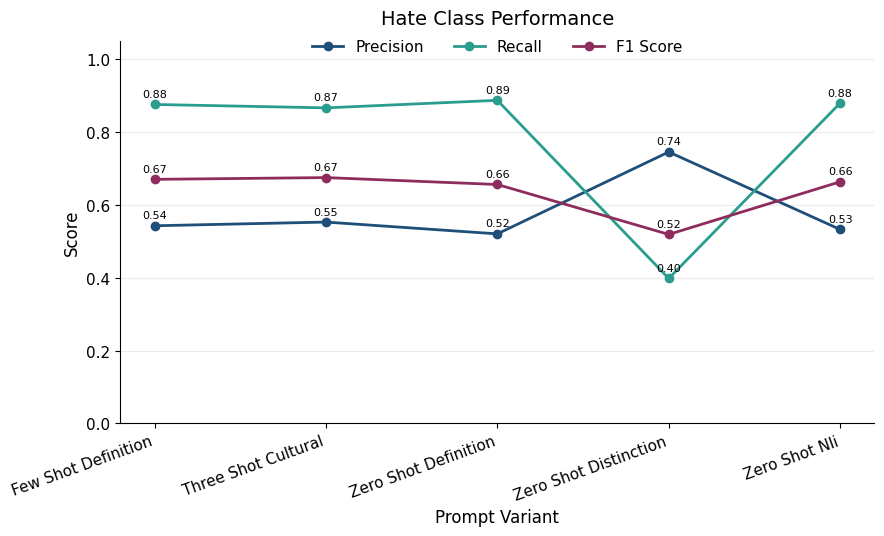

Saved: /content/comparison_outputs/fig_classwise_hate.png


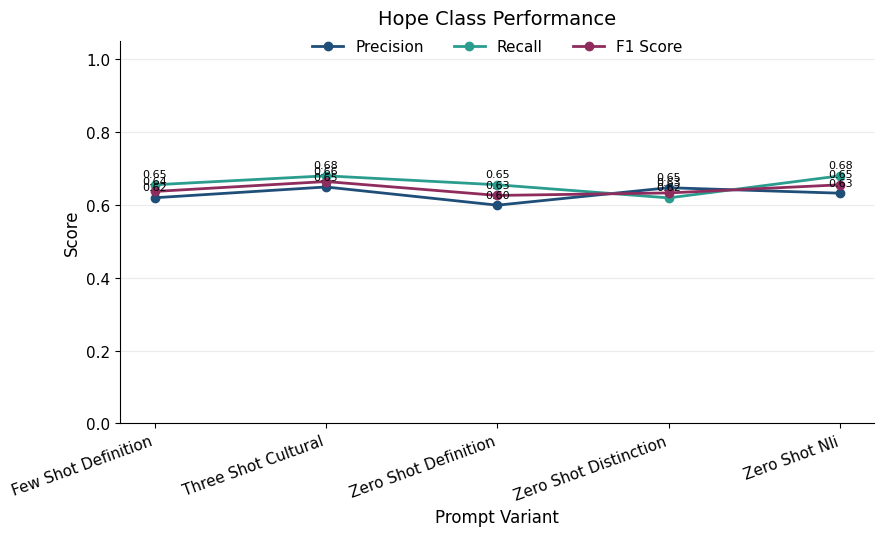

Saved: /content/comparison_outputs/fig_classwise_hope.png


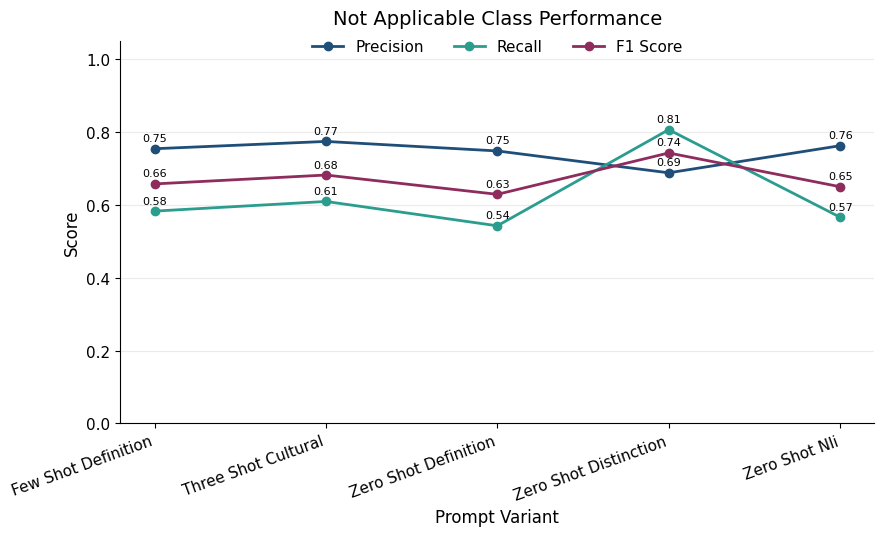

Saved: /content/comparison_outputs/fig_classwise_not_applicable.png


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_classwise_metrics_separate(per_class_df):
    """
    Expected columns:
    - prompt
    - label
    - precision
    - recall
    - f1
    """

    required_cols = {"prompt", "label", "precision", "recall", "f1"}
    missing_cols = required_cols - set(per_class_df.columns)
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    df = per_class_df.copy()

    # Keep prompt order as it appears
    prompt_order = df["prompt"].drop_duplicates().tolist()

    # Keep label order based on VALID_LABELS if available
    if "VALID_LABELS" in globals():
        label_order = [lab for lab in VALID_LABELS if lab in df["label"].unique()]
    else:
        label_order = df["label"].drop_duplicates().tolist()

    # Cleaner display names
    prompt_display = {
        p: str(p).replace("_", " ").title()
        for p in prompt_order
    }

    label_display = {
        l: str(l).replace("_", " ").title()
        for l in label_order
    }

    metric_display = {
        "precision": "Precision",
        "recall": "Recall",
        "f1": "F1 Score"
    }

    colors = {
        "precision": "#1f4e79",   # navy
        "recall": "#2a9d8f",      # teal
        "f1": "#8e2c5d"           # plum
    }

    plt.rcParams["font.family"] = "DejaVu Sans"
    plt.rcParams["font.size"] = 11

    x = np.arange(len(prompt_order))

    for label in label_order:
        sub = df[df["label"] == label].copy()
        sub = sub.set_index("prompt").reindex(prompt_order)

        fig, ax = plt.subplots(figsize=(9, 5.5))

        for metric in ["precision", "recall", "f1"]:
            y = sub[metric].values

            ax.plot(
                x,
                y,
                marker="o",
                linewidth=2,
                label=metric_display[metric],
                color=colors[metric]
            )

            # annotate points
            for xi, yi in zip(x, y):
                if not np.isnan(yi):
                    ax.text(
                        xi,
                        yi + 0.015,
                        f"{yi:.2f}",
                        ha="center",
                        va="bottom",
                        fontsize=8
                    )

        ax.set_title(f"{label_display[label]} Class Performance", fontsize=14, pad=12)
        ax.set_xlabel("Prompt Variant", fontsize=12)
        ax.set_ylabel("Score", fontsize=12)
        ax.set_ylim(0, 1.05)
        ax.set_xticks(x)
        ax.set_xticklabels(
            [prompt_display[p] for p in prompt_order],
            rotation=20,
            ha="right"
        )

        ax.yaxis.grid(True, linestyle="-", alpha=0.25)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Each figure gets its own legend
        ax.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, 1.04),
            ncol=3,
            frameon=False
        )

        plt.tight_layout()

        safe_label = str(label).lower().replace(" ", "_")
        out_path = os.path.join(OUTPUT_DIR, f"fig_classwise_{safe_label}.png")
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.show()

        print("Saved:", out_path)

plot_classwise_metrics_separate(per_class_recomputed)

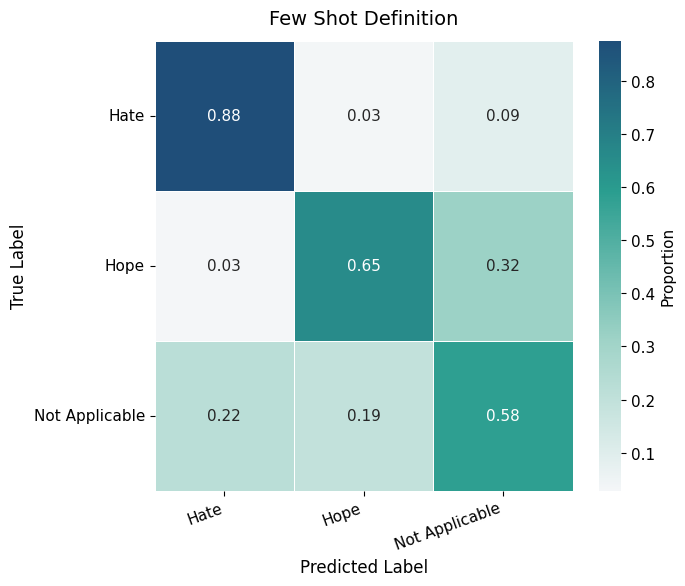

Saved: /content/comparison_outputs/fig_cm_few_shot_definition_normalized.png


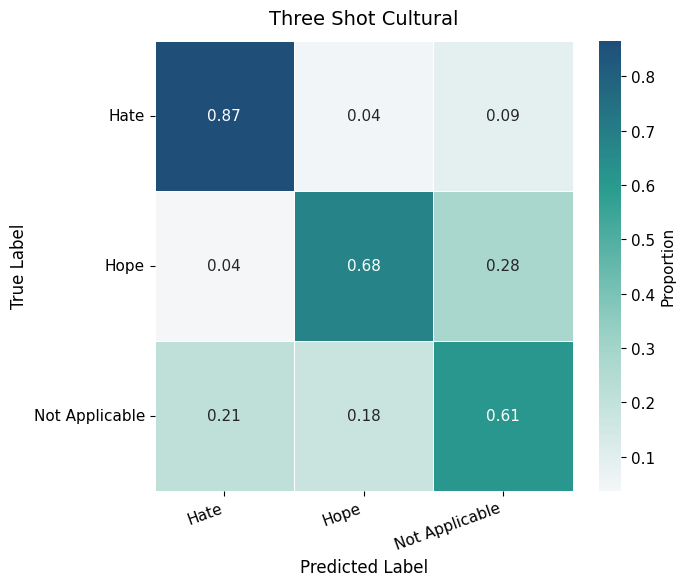

Saved: /content/comparison_outputs/fig_cm_three_shot_cultural_normalized.png


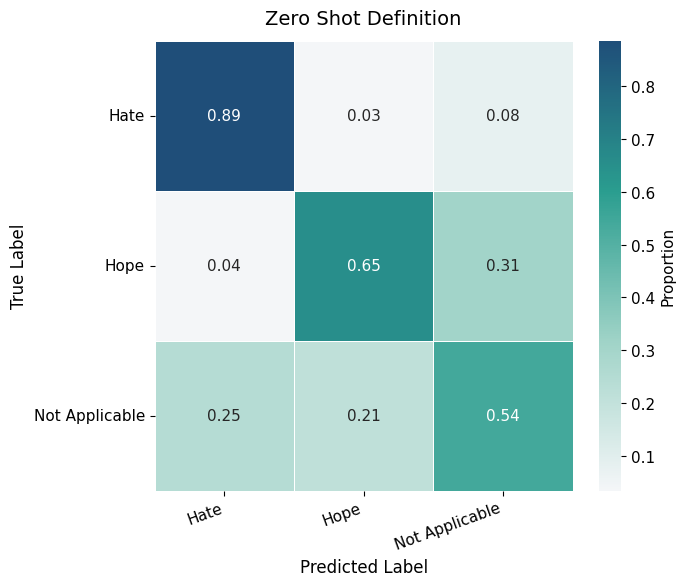

Saved: /content/comparison_outputs/fig_cm_zero_shot_definition_normalized.png


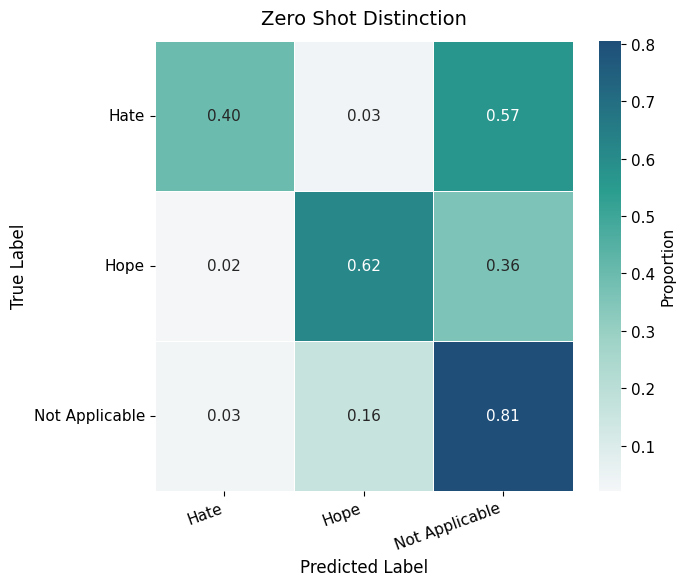

Saved: /content/comparison_outputs/fig_cm_zero_shot_distinction_normalized.png


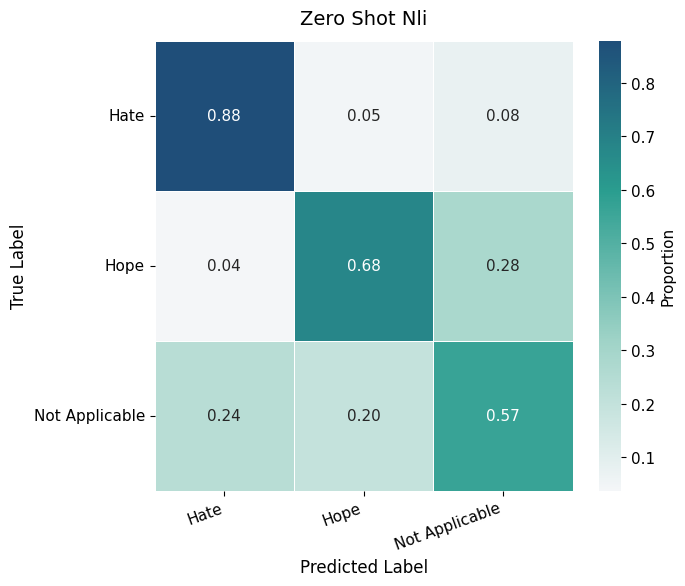

Saved: /content/comparison_outputs/fig_cm_zero_shot_nli_normalized.png


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap

def plot_confusion_matrices(results_all, normalize=False):
    # Clean professional font
    plt.rcParams["font.family"] = "DejaVu Sans"
    plt.rcParams["font.size"] = 11

    # Custom palette inspired by your sample chart
    # light -> teal -> navy
    cmap = LinearSegmentedColormap.from_list(
        "custom_cm",
        ["#f4f6f8", "#9fd3c7", "#2a9d8f", "#1f4e79"]
    )

    # Optional: cleaner display names for labels
    label_map = {
        label: label.replace("_", " ").title()
        for label in VALID_LABELS
    }
    display_labels = [label_map[label] for label in VALID_LABELS]

    for prompt_name, df_prompt in results_all.groupby("prompt_short"):
        valid_df = df_prompt[df_prompt["is_valid_eval"]].copy()
        if len(valid_df) == 0:
            continue

        y_true = valid_df["gold"].tolist()
        y_pred = valid_df["pred"].tolist()

        cm = confusion_matrix(y_true, y_pred, labels=VALID_LABELS)

        if normalize:
            cm_plot = np.divide(
                cm.astype(float),
                cm.sum(axis=1, keepdims=True),
                where=cm.sum(axis=1, keepdims=True) != 0
            )
            cm_plot = np.nan_to_num(cm_plot)
            fmt = ".2f"
            suffix = "normalized"
            title = f"{str(prompt_name).replace('_', ' ').title()}"
            cbar_label = "Proportion"
        else:
            cm_plot = cm
            fmt = "d"
            suffix = "counts"
            title = f"Confusion Matrix — {str(prompt_name).replace('_', ' ').title()}"
            cbar_label = "Count"

        plt.figure(figsize=(7, 6))
        ax = sns.heatmap(
            cm_plot,
            annot=True,
            fmt=fmt,
            cmap=cmap,
            xticklabels=display_labels,
            yticklabels=display_labels,
            linewidths=0.5,
            linecolor="white",
            cbar_kws={"label": cbar_label}
        )

        ax.set_xlabel("Predicted Label", fontsize=12)
        ax.set_ylabel("True Label", fontsize=12)
        ax.set_title(title, fontsize=14, pad=12)

        plt.xticks(rotation=20, ha="right")
        plt.yticks(rotation=0)
        plt.tight_layout()

        out_path = os.path.join(OUTPUT_DIR, f"fig_cm_{prompt_name}_{suffix}.png")
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.show()

        print("Saved:", out_path)


plot_confusion_matrices(results_all, normalize=True)
# plot_confusion_matrices(results_all, normalize=False)

In [ ]:
pred_dist = (
    results_all[results_all["is_valid_eval"]]
    .groupby(["prompt_short", "pred"])
    .size()
    .reset_index(name="count")
)

pred_dist["percentage"] = pred_dist.groupby("prompt_short")["count"].transform(lambda x: x / x.sum())

display(pred_dist)

pred_dist.to_csv(os.path.join(OUTPUT_DIR, "prediction_distribution_by_prompt.csv"), index=False)

,prompt_short,pred,count,percentage
0,few_shot_definition,hate,142,0.284000
1,few_shot_definition,hope,147,0.294000
2,few_shot_definition,not_applicable,211,0.422000
3,three_shot_cultural,hate,105,0.280000
4,three_shot_cultural,hope,111,0.296000
5,three_shot_cultural,not_applicable,159,0.424000
6,zero_shot_definition,hate,150,0.300000
7,zero_shot_definition,hope,152,0.304000
8,zero_shot_definition,not_applicable,198,0.396000
9,zero_shot_distinction,hate,47,0.094000


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest


def exact_mcnemar_pvalue(n01, n10):
    n = n01 + n10

    if n == 0:
        return 1.0

    return binomtest(
        k=min(n01, n10),
        n=n,
        p=0.5,
        alternative="two-sided"
    ).pvalue


def clean_prompt_name(name):
    return str(name).replace("_", " ").title()

In [ ]:
def compute_prompt_comparison_stats(
    results_all,
    baseline_prompt="zero_shot_definition",
    prompt_col="prompt_short",
    gold_col="gold",
    pred_col="pred",
    id_col=None
):
    """
    Computes:
    - McNemar n01 and n10
    - exact McNemar p-value
    - prediction flip rate

    If id_col is None, the function uses row order within each prompt.
    This avoids the duplicated sample_id problem.
    """

    df = results_all.copy()

    # Keep only valid rows
    df = df[df["processed_bool"] & df["is_valid_eval"]].copy()

    # Avoid duplicate column names
    df = df.loc[:, ~df.columns.duplicated()].copy()

    # Create pairing key
    if id_col is not None:
        if id_col not in df.columns:
            raise ValueError(f"id_col='{id_col}' was not found in results_all.")
        pair_col = id_col

    else:
        # Prefer text-based pairing if available
        possible_text_cols = ["text", "tweet", "content", "sentence"]

        text_col = None
        for col in possible_text_cols:
            if col in df.columns:
                text_col = col
                break

        if text_col is not None:
            pair_col = "__pair_id__"
            df[pair_col] = df[text_col].astype(str)
        else:
            # Fallback: pair by row order inside each prompt
            pair_col = "__pair_id__"
            df[pair_col] = df.groupby(prompt_col).cumcount()

    prompts = df[prompt_col].drop_duplicates().tolist()

    if baseline_prompt not in prompts:
        raise ValueError(
            f"Baseline prompt '{baseline_prompt}' not found.\n"
            f"Available prompts are:\n{prompts}"
        )

    baseline_df = df[df[prompt_col] == baseline_prompt][
        [pair_col, gold_col, pred_col]
    ].copy()

    baseline_df = baseline_df.rename(columns={
        gold_col: "gold_base",
        pred_col: "pred_base"
    })

    baseline_df["correct_base"] = baseline_df["gold_base"] == baseline_df["pred_base"]

    rows = []

    for other_prompt in prompts:
        if other_prompt == baseline_prompt:
            continue

        other_df = df[df[prompt_col] == other_prompt][
            [pair_col, gold_col, pred_col]
        ].copy()

        other_df = other_df.rename(columns={
            gold_col: "gold_other",
            pred_col: "pred_other"
        })

        other_df["correct_other"] = other_df["gold_other"] == other_df["pred_other"]

        paired = baseline_df.merge(
            other_df,
            on=pair_col,
            how="inner"
        )

        if len(paired) == 0:
            print(f"Skipping {other_prompt}: no paired samples found.")
            continue

        # Optional check: gold labels should match after pairing
        gold_mismatch = int((paired["gold_base"] != paired["gold_other"]).sum())

        # n01: baseline correct, other wrong
        n01 = int((paired["correct_base"] & ~paired["correct_other"]).sum())

        # n10: baseline wrong, other correct
        n10 = int((~paired["correct_base"] & paired["correct_other"]).sum())

        p_value = exact_mcnemar_pvalue(n01, n10)

        flip_rate = float((paired["pred_base"] != paired["pred_other"]).mean())

        rows.append({
            "baseline_prompt": baseline_prompt,
            "other_prompt": other_prompt,
            "paired_samples": len(paired),
            "gold_mismatches_after_pairing": gold_mismatch,
            "n01_base_correct_other_wrong": n01,
            "n10_base_wrong_other_correct": n10,
            "discordant_total": n01 + n10,
            "p_value": p_value,
            "significant_0_05": p_value < 0.05,
            "flip_rate": flip_rate
        })

    return pd.DataFrame(rows)

In [ ]:
comparison_stats = compute_prompt_comparison_stats(
    results_all,
    baseline_prompt="zero_shot_definition",
    id_col=None
)

display(comparison_stats)

,baseline_prompt,other_prompt,paired_samples,gold_mismatches_after_pairing,n01_base_correct_other_wrong,n10_base_wrong_other_correct,discordant_total,p_value,significant_0_05,flip_rate
0,zero_shot_definition,few_shot_definition,504,0,26,35,61,0.305677,False,0.125000
1,zero_shot_definition,three_shot_cultural,75,0,4,6,10,0.753906,False,0.133333
2,zero_shot_definition,zero_shot_distinction,504,0,62,87,149,0.048915,True,0.307540
3,zero_shot_definition,zero_shot_nli,373,0,20,31,51,0.160780,False,0.147453


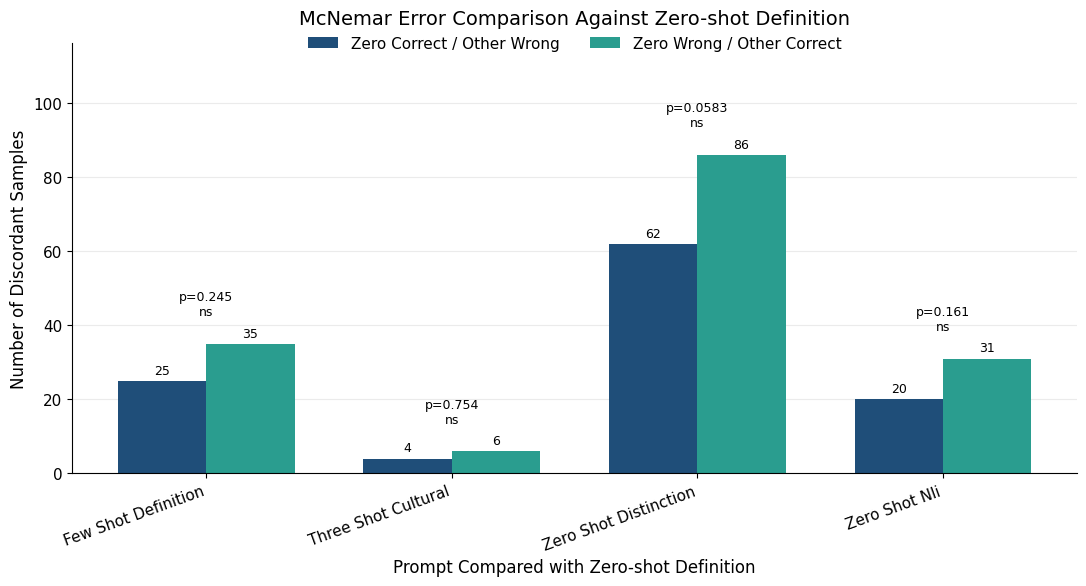

Saved: /content/comparison_outputs/fig_mcnemar_discordance.png


In [ ]:
def plot_mcnemar_discordance(comparison_df):
    df = comparison_df.copy()
    df["display_prompt"] = df["other_prompt"].apply(clean_prompt_name)

    plt.rcParams["font.family"] = "DejaVu Sans"
    plt.rcParams["font.size"] = 11

    x = np.arange(len(df))
    width = 0.36

    fig, ax = plt.subplots(figsize=(11, 6))

    bars1 = ax.bar(
        x - width / 2,
        df["n01_base_correct_other_wrong"],
        width,
        label="Zero Correct / Other Wrong",
        color="#1f4e79"
    )

    bars2 = ax.bar(
        x + width / 2,
        df["n10_base_wrong_other_correct"],
        width,
        label="Zero Wrong / Other Correct",
        color="#2a9d8f"
    )

    ax.bar_label(bars1, fontsize=9, padding=3)
    ax.bar_label(bars2, fontsize=9, padding=3)

    ymax = max(
        df["n01_base_correct_other_wrong"].max(),
        df["n10_base_wrong_other_correct"].max()
    )

    if ymax == 0:
        ymax = 1

    for i, row in df.iterrows():
        sig = "*" if row["significant_0_05"] else "ns"

        ax.text(
            x[i],
            max(
                row["n01_base_correct_other_wrong"],
                row["n10_base_wrong_other_correct"]
            ) + ymax * 0.08,
            f"p={row['p_value']:.3g}\n{sig}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.set_title("McNemar Error Comparison Against Zero-shot Definition", fontsize=14, pad=14)
    ax.set_xlabel("Prompt Compared with Zero-shot Definition", fontsize=12)
    ax.set_ylabel("Number of Discordant Samples", fontsize=12)

    ax.set_xticks(x)
    ax.set_xticklabels(df["display_prompt"], rotation=20, ha="right")

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.05),
        ncol=2,
        frameon=False
    )

    ax.yaxis.grid(True, linestyle="-", alpha=0.25)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_ylim(0, ymax * 1.35)

    plt.tight_layout()

    out_path = os.path.join(OUTPUT_DIR, "fig_mcnemar_discordance.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

plot_mcnemar_discordance(comparison_stats)

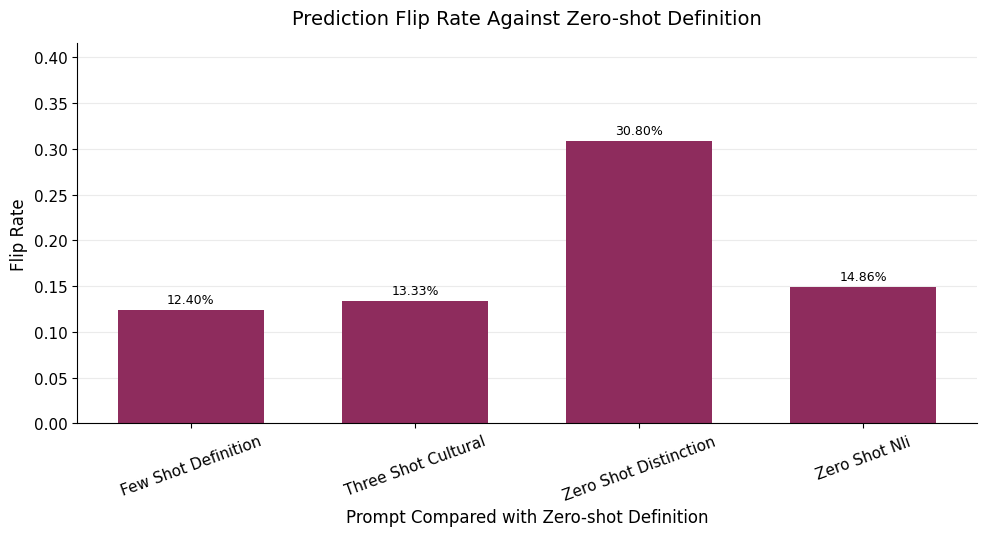

Saved: /content/comparison_outputs/fig_prompt_flip_rate.png


In [ ]:
def plot_flip_rate(comparison_df):
    df = comparison_df.copy()
    df["display_prompt"] = df["other_prompt"].apply(clean_prompt_name)

    plt.rcParams["font.family"] = "DejaVu Sans"
    plt.rcParams["font.size"] = 11

    fig, ax = plt.subplots(figsize=(10, 5.5))

    bars = ax.bar(
        df["display_prompt"],
        df["flip_rate"],
        color="#8e2c5d",
        width=0.65
    )

    ax.bar_label(
        bars,
        labels=[f"{v:.2%}" for v in df["flip_rate"]],
        fontsize=9,
        padding=3
    )

    ax.set_title("Prediction Flip Rate Against Zero-shot Definition", fontsize=14, pad=14)
    ax.set_xlabel("Prompt Compared with Zero-shot Definition", fontsize=12)
    ax.set_ylabel("Flip Rate", fontsize=12)

    upper = df["flip_rate"].max() * 1.25 + 0.03
    ax.set_ylim(0, min(1.0, upper))

    ax.tick_params(axis="x", rotation=20)

    ax.yaxis.grid(True, linestyle="-", alpha=0.25)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    out_path = os.path.join(OUTPUT_DIR, "fig_prompt_flip_rate.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)
plot_flip_rate(comparison_stats)

In [ ]:
import os
import pandas as pd
import numpy as np

SAMPLE_PATH = "/content/mahed_val_subset_500.csv"  # adjust extension if needed

samples_df = pd.read_csv(SAMPLE_PATH)

display(samples_df.head())
print(samples_df.columns)

,sample_id,id,text,label
0,0,7378,ممكن مبادل نحيف مره لاربعيني رجولي #مبادل_الطا...,not_applicable
1,1,641,لَا أَسْتَطِيعُ أَنْ أُبْذِلَ الْجُرْأَةَ لِأُ...,hate
2,2,2413,دولة جزر القمر تقوم بخطوات سريعة وقرارات سليمة...,not_applicable
3,3,7685,: اللهم اصلح شان اخواننا المسلمين اهل السنه في...,hope
4,4,1346,. أَشْعُرُ بِالْفَخْرِ لِحُصُولِي عَلَى هَذِهِ...,hope


Index(['sample_id', 'id', 'text', 'label'], dtype='object')


In [ ]:
["sample_id", "id", "text", "label"]

['sample_id', 'id', 'text', 'label']

In [ ]:
def standardize_samples_df(samples_df):
    samples_df = samples_df.copy()

    # Remove duplicated columns if any
    samples_df = samples_df.loc[:, ~samples_df.columns.duplicated()].copy()

    required_cols = {"sample_id", "id", "text", "label"}
    missing = required_cols - set(samples_df.columns)

    if missing:
        raise ValueError(f"Missing columns in sample file: {missing}")

    samples_df["gold_from_sample_file"] = (
        samples_df["label"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    return samples_df


samples_df = standardize_samples_df(samples_df)

Summary files merged: (5, 18)
Per-class files merged: (15, 7)
Row-level result files merged: (2500, 12)
Gold mismatches with sample file: 0

Prompts found:
['few_shot_definition', 'three_shot_cultural', 'zero_shot_definition', 'zero_shot_distinction', 'zero_shot_nli']

Saved: /content/comparison_outputs/prompt_mcnemar_fliprate_stats.csv


,baseline_prompt,other_prompt,paired_samples,n01_base_correct_other_wrong,n10_base_wrong_other_correct,discordant_total,p_value,significant_0_05,flip_rate
0,zero_shot_definition,few_shot_definition,500,25,35,60,0.245061,False,0.124000
1,zero_shot_definition,three_shot_cultural,375,14,34,48,0.005515,True,0.130667
2,zero_shot_definition,zero_shot_distinction,500,62,86,148,0.058312,False,0.308000
3,zero_shot_definition,zero_shot_nli,370,20,31,51,0.160780,False,0.148649


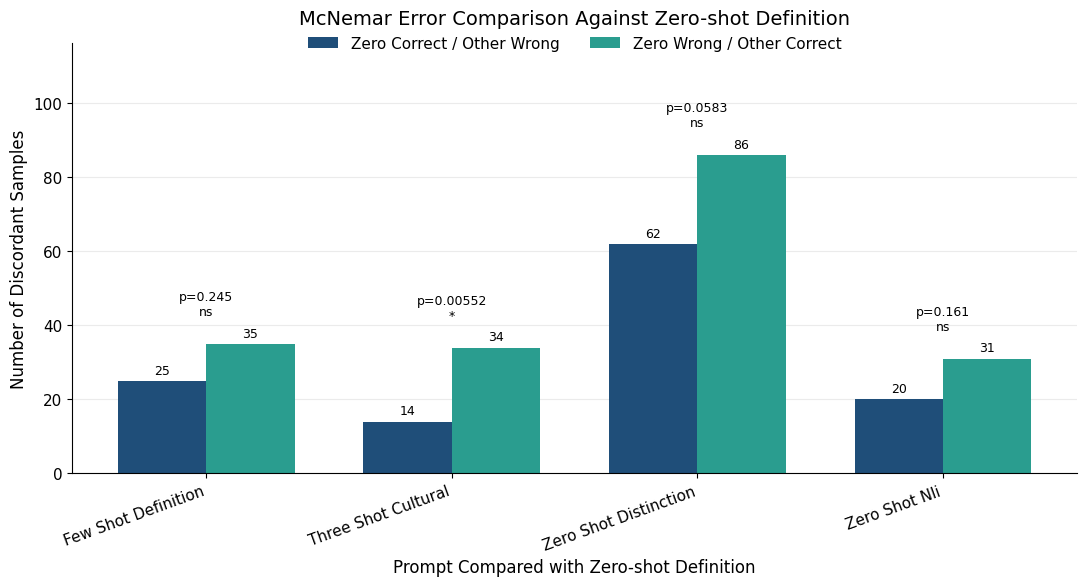

Saved: /content/comparison_outputs/fig_mcnemar_discordance.png


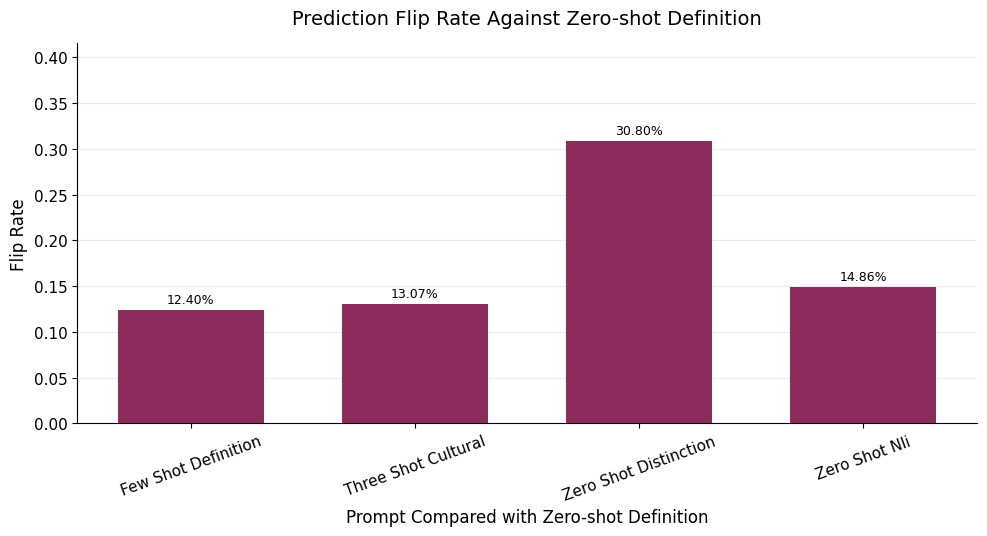

Saved: /content/comparison_outputs/fig_prompt_flip_rate.png

Saved: /content/comparison_outputs/ANNOTATE_group_A_shared_failures.csv


,sample_id,id,text,gold,pred__few_shot_definition,pred__three_shot_cultural,pred__zero_shot_definition,pred__zero_shot_distinction,pred__zero_shot_nli,num_correct_prompts,manual_error_category,manual_notes,possible_categories
0,214,2996,: مبروك اول بطوله رسميه لبايرن انشيلوتي ! السو...,not_applicable,hope,hope,hope,hope,hope,0,,,label_boundary_ambiguity; general_toxicity_con...
1,1,641,لَا أَسْتَطِيعُ أَنْ أُبْذِلَ الْجُرْأَةَ لِأُ...,hate,not_applicable,not_applicable,not_applicable,not_applicable,not_applicable,0,,,label_boundary_ambiguity; general_toxicity_con...
2,156,6064,@ali_al_dahab ي علي ذهب حرر أرضك انت .. صحح مع...,hate,not_applicable,not_applicable,not_applicable,not_applicable,not_applicable,0,,,label_boundary_ambiguity; general_toxicity_con...
3,215,8806,وحشني احساسك وحشني حبك المجنون وحشني صدرك الدا...,not_applicable,hope,hope,hope,hope,hope,0,,,label_boundary_ambiguity; general_toxicity_con...
4,123,4562,ياصباح الخير والتايم كله مزز الاوليمبياد,hope,not_applicable,not_applicable,not_applicable,not_applicable,not_applicable,0,,,label_boundary_ambiguity; general_toxicity_con...
5,203,1295,وَموقَرَةٍ بِثِقلِ الماءِ جاءَت تَهادى فَوقَ أ...,hope,not_applicable,not_applicable,not_applicable,not_applicable,not_applicable,0,,,label_boundary_ambiguity; general_toxicity_con...
6,75,3703,FCB الله يوفقكم قلوبنا معكم ❤️,not_applicable,hope,hope,hope,hope,hope,0,,,label_boundary_ambiguity; general_toxicity_con...
7,410,7188,نَموتُ جَميعاً كُلُّنا غَيرَ ما شَكٍ وَلا أَحَ...,hope,not_applicable,NaN,not_applicable,not_applicable,NaN,0,,,label_boundary_ambiguity; general_toxicity_con...
8,27,9476,ما شفائي إلا النبيذُ فما رأ يكِ في أن تجودَ لي...,hope,not_applicable,not_applicable,not_applicable,not_applicable,not_applicable,0,,,label_boundary_ambiguity; general_toxicity_con...
9,88,7809,@aurrassi @jebren_ صحراء سوف تتحرر ونهايتكم قر...,not_applicable,hate,hate,hate,hate,hate,0,,,label_boundary_ambiguity; general_toxicity_con...



Saved: /content/comparison_outputs/ANNOTATE_group_B_prompt_specific.csv


,comparison,case_type,sample_id,id,text,gold,pred__zero_shot_definition,pred__few_shot_definition,pred__three_shot_cultural,pred__zero_shot_distinction,pred__zero_shot_nli,manual_error_category,manual_notes,possible_categories
0,zero_shot_definition vs few_shot_definition,baseline_wrong_other_correct,336,7362,دارٌ لموسَى بْنِ بَنْبِينُو مُبارَكةٌ لا زالَ ...,not_applicable,hope,not_applicable,NaN,NaN,NaN,,,label_boundary_ambiguity; general_toxicity_con...
1,zero_shot_definition vs few_shot_definition,baseline_wrong_other_correct,254,8206,أنا المحيي لا أكنى ولا أتبلد أنا العربيُّ الحا...,not_applicable,hope,not_applicable,NaN,NaN,NaN,,,label_boundary_ambiguity; general_toxicity_con...
2,zero_shot_definition vs few_shot_definition,baseline_wrong_other_correct,311,8501,، أَعْتَقِدُ أَنَّنِي يَجِبُ أَنْ أَشْعُرَ بِا...,hope,not_applicable,hope,NaN,NaN,NaN,,,label_boundary_ambiguity; general_toxicity_con...
3,zero_shot_definition vs few_shot_definition,baseline_wrong_other_correct,298,4129,: الرجُلْ حينَ يَعشقْ : يعُود طِفلاً .. والاُن...,not_applicable,hope,not_applicable,NaN,NaN,NaN,,,label_boundary_ambiguity; general_toxicity_con...
4,zero_shot_definition vs few_shot_definition,baseline_wrong_other_correct,265,6006,انا متضامن مع الحمله ضد stc اليوم 75 stc راح ن...,not_applicable,hate,not_applicable,NaN,NaN,NaN,,,label_boundary_ambiguity; general_toxicity_con...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,zero_shot_definition vs zero_shot_nli,baseline_correct_other_wrong,443,2166,عندما تتحدثون عن الطرب يجب عليكم ذكر رنا سماحه...,hope,hope,NaN,NaN,NaN,NaN,,,label_boundary_ambiguity; general_toxicity_con...
76,zero_shot_definition vs zero_shot_nli,baseline_correct_other_wrong,385,6913,روح الله يخيبك سلفنجي وهابي 100 نقطه مقابل لا ...,hate,hate,NaN,NaN,NaN,NaN,,,label_boundary_ambiguity; general_toxicity_con...
77,zero_shot_definition vs zero_shot_nli,baseline_correct_other_wrong,390,2982,احسن حاجه ان مصر مش بتنافس في الاوليمبياد يعتب...,not_applicable,not_applicable,NaN,NaN,NaN,NaN,,,label_boundary_ambiguity; general_toxicity_con...
78,zero_shot_definition vs zero_shot_nli,baseline_correct_other_wrong,484,5479,مملكة شامبالا: هي مملكة أسطورية مخفية تعد من ا...,not_applicable,not_applicable,NaN,NaN,NaN,NaN,,,label_boundary_ambiguity; general_toxicity_con...



Saved: /content/comparison_outputs/ANNOTATE_group_C_hate_errors.csv


,prompt_short,error_type,sample_id,id,text,gold,pred,manual_error_category,manual_notes,possible_categories
0,few_shot_definition,hate_false_positive,402,8667,@MeirMasri هزيمة ساحقة؟صلي عالنبي انت مابعرف ا...,not_applicable,hate,,,label_boundary_ambiguity; general_toxicity_con...
1,few_shot_definition,hate_false_positive,445,8672,@Dhahi_Khalfan اكيد الجنوبيين ناس كبار ومسالمي...,not_applicable,hate,,,label_boundary_ambiguity; general_toxicity_con...
2,few_shot_definition,hate_false_positive,2,2413,دولة جزر القمر تقوم بخطوات سريعة وقرارات سليمة...,not_applicable,hate,,,label_boundary_ambiguity; general_toxicity_con...
3,few_shot_definition,hate_false_positive,343,7516,@khalidjassem74 فوز الدحيل بشرط القواطي ماتكون...,not_applicable,hate,,,label_boundary_ambiguity; general_toxicity_con...
4,few_shot_definition,hate_false_positive,31,5306,@o9gJchiGR3FqA1d @hureyaksa والله انك كذاب الس...,not_applicable,hate,,,label_boundary_ambiguity; general_toxicity_con...
...,...,...,...,...,...,...,...,...,...,...
92,zero_shot_nli,hate_false_negative,130,858,بكى الناسُ قبليَ فَقْدَ الشبابِ بدمعِ القلوبِ ...,hate,not_applicable,,,label_boundary_ambiguity; general_toxicity_con...
93,zero_shot_nli,hate_false_negative,153,8147,@Aldowayesh الوطن في قلوب جميع الاندية ولا يقت...,hate,hope,,,label_boundary_ambiguity; general_toxicity_con...
94,zero_shot_nli,hate_false_negative,156,6064,@ali_al_dahab ي علي ذهب حرر أرضك انت .. صحح مع...,hate,not_applicable,,,label_boundary_ambiguity; general_toxicity_con...
95,zero_shot_nli,hate_false_negative,333,1071,اسمعوا من ينتقد خرافات الاديان🤦‍♂️ العلامة عثم...,hate,not_applicable,,,label_boundary_ambiguity; general_toxicity_con...


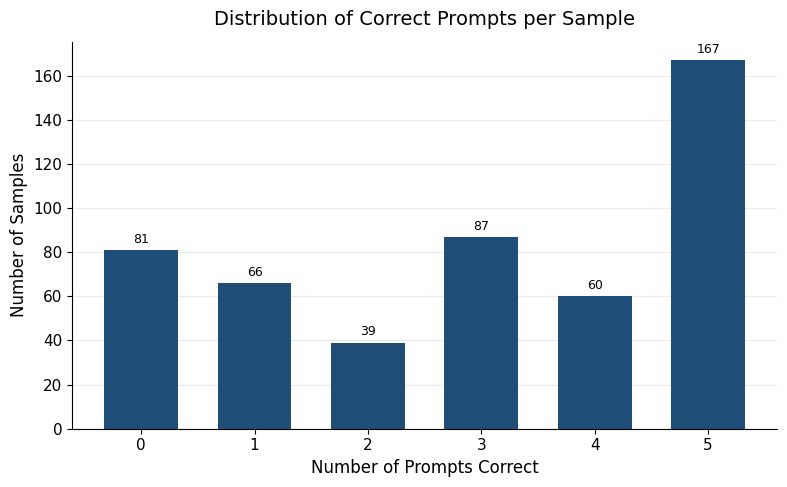

Saved: /content/comparison_outputs/fig_error_num_correct_prompts.png


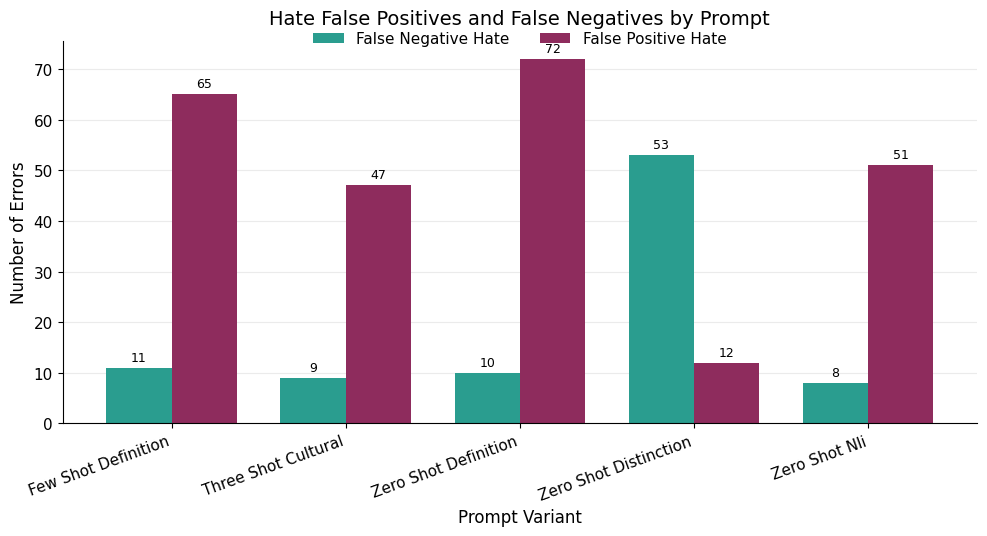

Saved: /content/comparison_outputs/fig_hate_fp_fn_by_prompt.png

Done. Outputs saved in:
/content/comparison_outputs


In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest

# ============================================================
# CONFIG
# ============================================================

VALID_LABELS = ["hate", "hope", "not_applicable"]

RESULTS_DIR = "/content/"
OUTPUT_DIR = os.path.join(RESULTS_DIR, "comparison_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAMPLE_PATH = "/content/mahed_val_subset_500.csv"

BASELINE_PROMPT = "zero_shot_definition"

ERROR_CATEGORIES = [
    "label_boundary_ambiguity",
    "general_toxicity_confused_with_hate",
    "political_criticism",
    "religious_or_cultural_phrasing",
    "sarcasm_or_irony",
    "implicit_hate",
    "dialectal_wording",
    "code_mixing_or_arabizi",
    "annotation_ambiguity",
    "other"
]


# ============================================================
# HELPERS
# ============================================================

def clean_prompt_name(name):
    return str(name).replace("_", " ").title()


def normalize_label(x):
    x = str(x).strip().lower()
    x = x.replace(" ", "").replace("\n", "").replace("\t", "")

    mapping = {
        "hate": "hate",
        "hope": "hope",
        "not_applicable": "not_applicable",
        "notapplicable": "not_applicable",
        "not-applicable": "not_applicable",
        "invalid": "INVALID",
        "error": "ERROR",
        "nan": "INVALID",
        "": "INVALID"
    }

    return mapping.get(x, x)


def infer_prompt_name_from_path(path):
    name = os.path.basename(path)
    name = name.replace(".csv", "")

    if name.startswith("metrics_summary"):
        return name.replace("metrics_summary", "")

    if name.startswith("metrics_per_class_"):
        return name.replace("metrics_per_class_", "")

    if name.startswith("results_"):
        x = name.replace("results_", "")
        x = x.replace("_gemini_2_5_flash", "")
        x = x.replace("_gemini_3_flash_preview", "")
        return x

    return name


def exact_mcnemar_pvalue(n01, n10):
    n = n01 + n10

    if n == 0:
        return 1.0

    return binomtest(
        k=min(n01, n10),
        n=n,
        p=0.5,
        alternative="two-sided"
    ).pvalue


# ============================================================
# LOAD AND STANDARDIZE FILES
# ============================================================

def load_all_prompt_files(results_dir):
    summary_files = sorted(glob.glob(os.path.join(results_dir, "metrics_summary*.csv")))
    per_class_files = sorted(glob.glob(os.path.join(results_dir, "metrics_per_class*.csv")))
    result_files = sorted(glob.glob(os.path.join(results_dir, "results_*.csv")))

    summary_frames = []
    per_class_frames = []
    result_frames = []

    for path in summary_files:
        df = pd.read_csv(path)
        df = df.loc[:, ~df.columns.duplicated()].copy()

        if "prompt_short" not in df.columns:
            df["prompt_short"] = infer_prompt_name_from_path(path)

        summary_frames.append(df)

    for path in per_class_files:
        df = pd.read_csv(path)
        df = df.loc[:, ~df.columns.duplicated()].copy()

        if "prompt_short" not in df.columns:
            df["prompt_short"] = infer_prompt_name_from_path(path)

        per_class_frames.append(df)

    for path in result_files:
        df = pd.read_csv(path)
        df = df.loc[:, ~df.columns.duplicated()].copy()

        if "prompt_short" not in df.columns:
            df["prompt_short"] = infer_prompt_name_from_path(path)

        result_frames.append(df)

    summary_all = pd.concat(summary_frames, ignore_index=True) if summary_frames else pd.DataFrame()
    per_class_all = pd.concat(per_class_frames, ignore_index=True) if per_class_frames else pd.DataFrame()
    results_all = pd.concat(result_frames, ignore_index=True) if result_frames else pd.DataFrame()

    return summary_all, per_class_all, results_all


def standardize_results_df(df):
    df = df.copy()
    df = df.loc[:, ~df.columns.duplicated()].copy()

    if "gold" not in df.columns:
        if "label" in df.columns:
            df["gold"] = df["label"]
        else:
            raise ValueError("No gold or label column found.")

    if "pred" not in df.columns:
        raise ValueError("No pred column found.")

    df["gold"] = df["gold"].astype(str).str.strip().str.lower()
    df["pred"] = df["pred"].apply(normalize_label)

    if "processed" in df.columns:
        df["processed_bool"] = (
            df["processed"]
            .astype(str)
            .str.lower()
            .isin(["true", "1", "yes"])
        )
    else:
        df["processed_bool"] = True

    df["is_valid_gold"] = df["gold"].isin(VALID_LABELS)
    df["is_valid_pred"] = df["pred"].isin(VALID_LABELS)
    df["is_valid_eval"] = df["processed_bool"] & df["is_valid_gold"] & df["is_valid_pred"]
    df["correct_eval"] = (df["gold"] == df["pred"]).astype(int)

    return df


def standardize_samples_df(samples_df):
    samples_df = samples_df.copy()
    samples_df = samples_df.loc[:, ~samples_df.columns.duplicated()].copy()

    required_cols = {"sample_id", "id", "text", "label"}
    missing = required_cols - set(samples_df.columns)

    if missing:
        raise ValueError(f"Missing columns in sample file: {missing}")

    samples_df["sample_id"] = samples_df["sample_id"].astype(int)

    samples_df["gold_from_sample_file"] = (
        samples_df["label"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    return samples_df


# ============================================================
# ERROR ANALYSIS PREPARATION
# ============================================================

def prepare_results_for_error_analysis(results_all, samples_df):
    df = results_all.copy()
    df = df.loc[:, ~df.columns.duplicated()].copy()

    df = df[df["processed_bool"] & df["is_valid_eval"]].copy()

    if "sample_id" not in df.columns:
        df["sample_id"] = df.groupby("prompt_short").cumcount()

    df["sample_id"] = df["sample_id"].astype(int)

    samples_df = samples_df.copy()
    samples_df["sample_id"] = samples_df["sample_id"].astype(int)

    # Rename sample-file columns before merge to avoid text_x / text_y problems
    sample_keep = samples_df[
        ["sample_id", "id", "text", "gold_from_sample_file"]
    ].copy()

    sample_keep = sample_keep.rename(columns={
        "id": "dataset_id",
        "text": "sample_text"
    })

    df = df.merge(
        sample_keep,
        on="sample_id",
        how="left"
    )

    # Create final clean id/text columns
    if "id" in df.columns:
        df["original_result_id"] = df["id"]

    df["id"] = df["dataset_id"]
    df["text"] = df["sample_text"]

    df["gold"] = df["gold"].astype(str).str.strip().str.lower()

    df["gold_mismatch_with_sample_file"] = (
        df["gold"] != df["gold_from_sample_file"]
    )

    mismatch_count = int(df["gold_mismatch_with_sample_file"].sum())
    print("Gold mismatches with sample file:", mismatch_count)

    if mismatch_count > 0:
        print("Warning: inspect gold mismatches before trusting the error analysis.")

    return df


def make_wide_prediction_table(results_error):
    df = results_error.copy()
    df = df.loc[:, ~df.columns.duplicated()].copy()

    # Safety fallback if text is still missing
    if "text" not in df.columns:
        if "sample_text" in df.columns:
            df["text"] = df["sample_text"]
        elif "text_y" in df.columns:
            df["text"] = df["text_y"]
        elif "text_x" in df.columns:
            df["text"] = df["text_x"]
        else:
            df["text"] = ""

    # Safety fallback if id is missing
    if "id" not in df.columns:
        if "dataset_id" in df.columns:
            df["id"] = df["dataset_id"]
        elif "id_y" in df.columns:
            df["id"] = df["id_y"]
        elif "id_x" in df.columns:
            df["id"] = df["id_x"]
        else:
            df["id"] = ""

    base_cols = ["sample_id", "id", "text", "gold"]

    meta_df = (
        df[base_cols]
        .drop_duplicates(subset=["sample_id"])
        .sort_values("sample_id")
        .copy()
    )

    pred_wide = df.pivot_table(
        index="sample_id",
        columns="prompt_short",
        values="pred",
        aggfunc="first"
    )

    pred_wide = pred_wide.add_prefix("pred__").reset_index()

    wide_df = meta_df.merge(pred_wide, on="sample_id", how="left")

    prompt_names = [
        col.replace("pred__", "")
        for col in wide_df.columns
        if col.startswith("pred__")
    ]

    for prompt in prompt_names:
        wide_df[f"correct__{prompt}"] = (
            wide_df[f"pred__{prompt}"] == wide_df["gold"]
        )

    return wide_df, prompt_names


# ============================================================
# MCNEMAR AND FLIP RATE
# ============================================================

def compute_prompt_comparison_stats_from_wide(
    wide_df,
    prompt_names,
    baseline_prompt=BASELINE_PROMPT
):
    if baseline_prompt not in prompt_names:
        raise ValueError(
            f"Baseline prompt '{baseline_prompt}' not found. "
            f"Available prompts: {prompt_names}"
        )

    rows = []

    for other_prompt in prompt_names:
        if other_prompt == baseline_prompt:
            continue

        base_correct_col = f"correct__{baseline_prompt}"
        other_correct_col = f"correct__{other_prompt}"

        base_pred_col = f"pred__{baseline_prompt}"
        other_pred_col = f"pred__{other_prompt}"

        needed = [
            base_correct_col,
            other_correct_col,
            base_pred_col,
            other_pred_col
        ]

        missing = [c for c in needed if c not in wide_df.columns]
        if missing:
            print(f"Skipping {other_prompt}. Missing columns: {missing}")
            continue

        paired = wide_df.dropna(subset=[base_pred_col, other_pred_col]).copy()

        base_correct = paired[base_correct_col]
        other_correct = paired[other_correct_col]

        n01 = int((base_correct & ~other_correct).sum())
        n10 = int((~base_correct & other_correct).sum())

        p_value = exact_mcnemar_pvalue(n01, n10)

        flip_rate = float((paired[base_pred_col] != paired[other_pred_col]).mean())

        rows.append({
            "baseline_prompt": baseline_prompt,
            "other_prompt": other_prompt,
            "paired_samples": len(paired),
            "n01_base_correct_other_wrong": n01,
            "n10_base_wrong_other_correct": n10,
            "discordant_total": n01 + n10,
            "p_value": p_value,
            "significant_0_05": p_value < 0.05,
            "flip_rate": flip_rate
        })

    return pd.DataFrame(rows)


def plot_mcnemar_discordance(comparison_df):
    df = comparison_df.copy()
    df["display_prompt"] = df["other_prompt"].apply(clean_prompt_name)

    plt.rcParams["font.family"] = "DejaVu Sans"
    plt.rcParams["font.size"] = 11

    x = np.arange(len(df))
    width = 0.36

    fig, ax = plt.subplots(figsize=(11, 6))

    bars1 = ax.bar(
        x - width / 2,
        df["n01_base_correct_other_wrong"],
        width,
        label="Zero Correct / Other Wrong",
        color="#1f4e79"
    )

    bars2 = ax.bar(
        x + width / 2,
        df["n10_base_wrong_other_correct"],
        width,
        label="Zero Wrong / Other Correct",
        color="#2a9d8f"
    )

    ax.bar_label(bars1, fontsize=9, padding=3)
    ax.bar_label(bars2, fontsize=9, padding=3)

    ymax = max(
        df["n01_base_correct_other_wrong"].max(),
        df["n10_base_wrong_other_correct"].max()
    )

    if ymax == 0:
        ymax = 1

    for i, row in df.iterrows():
        sig = "*" if row["significant_0_05"] else "ns"

        ax.text(
            x[i],
            max(
                row["n01_base_correct_other_wrong"],
                row["n10_base_wrong_other_correct"]
            ) + ymax * 0.08,
            f"p={row['p_value']:.3g}\n{sig}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.set_title("McNemar Error Comparison Against Zero-shot Definition", fontsize=14, pad=14)
    ax.set_xlabel("Prompt Compared with Zero-shot Definition", fontsize=12)
    ax.set_ylabel("Number of Discordant Samples", fontsize=12)

    ax.set_xticks(x)
    ax.set_xticklabels(df["display_prompt"], rotation=20, ha="right")

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.05),
        ncol=2,
        frameon=False
    )

    ax.yaxis.grid(True, linestyle="-", alpha=0.25)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_ylim(0, ymax * 1.35)

    plt.tight_layout()

    out_path = os.path.join(OUTPUT_DIR, "fig_mcnemar_discordance.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)


def plot_flip_rate(comparison_df):
    df = comparison_df.copy()
    df["display_prompt"] = df["other_prompt"].apply(clean_prompt_name)

    plt.rcParams["font.family"] = "DejaVu Sans"
    plt.rcParams["font.size"] = 11

    fig, ax = plt.subplots(figsize=(10, 5.5))

    bars = ax.bar(
        df["display_prompt"],
        df["flip_rate"],
        color="#8e2c5d",
        width=0.65
    )

    ax.bar_label(
        bars,
        labels=[f"{v:.2%}" for v in df["flip_rate"]],
        fontsize=9,
        padding=3
    )

    ax.set_title("Prediction Flip Rate Against Zero-shot Definition", fontsize=14, pad=14)
    ax.set_xlabel("Prompt Compared with Zero-shot Definition", fontsize=12)
    ax.set_ylabel("Flip Rate", fontsize=12)

    upper = df["flip_rate"].max() * 1.25 + 0.03
    ax.set_ylim(0, min(1.0, upper))

    ax.tick_params(axis="x", rotation=20)

    ax.yaxis.grid(True, linestyle="-", alpha=0.25)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    out_path = os.path.join(OUTPUT_DIR, "fig_prompt_flip_rate.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)


# ============================================================
# GROUP A: SHARED FAILURES
# ============================================================

def extract_shared_failures(wide_df, prompt_names, n=10, random_state=42):
    df = wide_df.copy()

    correct_cols = [f"correct__{p}" for p in prompt_names]

    df["num_correct_prompts"] = df[correct_cols].sum(axis=1)
    df["all_prompts_wrong"] = df["num_correct_prompts"] == 0

    pred_cols = [f"pred__{p}" for p in prompt_names]

    out = df[df["all_prompts_wrong"]].copy()

    cols = ["sample_id", "id", "text", "gold"] + pred_cols + ["num_correct_prompts"]
    out = out[cols]

    if len(out) > n:
        out = out.sample(n=n, random_state=random_state)

    return out.reset_index(drop=True)


# ============================================================
# GROUP B: PROMPT-SPECIFIC FAILURES
# ============================================================

def extract_prompt_specific_failures(
    wide_df,
    baseline_prompt,
    other_prompt,
    n=10,
    random_state=42
):
    df = wide_df.copy()

    base_correct_col = f"correct__{baseline_prompt}"
    other_correct_col = f"correct__{other_prompt}"

    base_pred_col = f"pred__{baseline_prompt}"
    other_pred_col = f"pred__{other_prompt}"

    required = {
        base_correct_col,
        other_correct_col,
        base_pred_col,
        other_pred_col
    }

    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    other_helps = df[
        (~df[base_correct_col]) & (df[other_correct_col])
    ].copy()

    other_helps["case_type"] = "baseline_wrong_other_correct"
    other_helps["comparison"] = f"{baseline_prompt} vs {other_prompt}"

    other_hurts = df[
        (df[base_correct_col]) & (~df[other_correct_col])
    ].copy()

    other_hurts["case_type"] = "baseline_correct_other_wrong"
    other_hurts["comparison"] = f"{baseline_prompt} vs {other_prompt}"

    cols = [
        "comparison",
        "case_type",
        "sample_id",
        "id",
        "text",
        "gold",
        base_pred_col,
        other_pred_col
    ]

    if len(other_helps) > n:
        other_helps = other_helps.sample(n=n, random_state=random_state)

    if len(other_hurts) > n:
        other_hurts = other_hurts.sample(n=n, random_state=random_state)

    other_helps = other_helps[cols].reset_index(drop=True)
    other_hurts = other_hurts[cols].reset_index(drop=True)

    return other_helps, other_hurts


def extract_all_prompt_specific_failures(
    wide_df,
    prompt_names,
    baseline_prompt=BASELINE_PROMPT,
    n=10,
    random_state=42
):
    group_B_all = []

    for other_prompt in prompt_names:
        if other_prompt == baseline_prompt:
            continue

        helps, hurts = extract_prompt_specific_failures(
            wide_df,
            baseline_prompt=baseline_prompt,
            other_prompt=other_prompt,
            n=n,
            random_state=random_state
        )

        group_B_all.append(helps)
        group_B_all.append(hurts)

    if not group_B_all:
        return pd.DataFrame()

    return pd.concat(group_B_all, ignore_index=True)


# ============================================================
# GROUP C: HATE FALSE POSITIVES / FALSE NEGATIVES
# ============================================================

def extract_hate_fp_fn_per_prompt(
    results_error,
    n=10,
    random_state=42
):
    df = results_error.copy()
    rows = []

    for prompt_name, sub in df.groupby("prompt_short"):
        sub = sub.copy()

        fp = sub[
            (sub["gold"] != "hate") & (sub["pred"] == "hate")
        ].copy()

        fp["error_type"] = "hate_false_positive"

        fn = sub[
            (sub["gold"] == "hate") & (sub["pred"] != "hate")
        ].copy()

        fn["error_type"] = "hate_false_negative"

        if len(fp) > n:
            fp = fp.sample(n=n, random_state=random_state)

        if len(fn) > n:
            fn = fn.sample(n=n, random_state=random_state)

        rows.append(fp)
        rows.append(fn)

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)

    cols = [
        "prompt_short",
        "error_type",
        "sample_id",
        "id",
        "text",
        "gold",
        "pred"
    ]

    return out[cols].reset_index(drop=True)


# ============================================================
# MANUAL ANNOTATION COLUMNS
# ============================================================

def add_manual_annotation_columns(df):
    df = df.copy()
    df["manual_error_category"] = ""
    df["manual_notes"] = ""
    df["possible_categories"] = "; ".join(ERROR_CATEGORIES)
    return df


# ============================================================
# OPTIONAL PLOTS FOR ERROR ANALYSIS
# ============================================================

def plot_shared_failure_count(wide_df, prompt_names):
    correct_cols = [f"correct__{p}" for p in prompt_names]

    df = wide_df.copy()
    df["num_correct_prompts"] = df[correct_cols].sum(axis=1)

    counts = df["num_correct_prompts"].value_counts().sort_index()

    plt.rcParams["font.family"] = "DejaVu Sans"
    plt.rcParams["font.size"] = 11

    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.bar(
        counts.index.astype(str),
        counts.values,
        color="#1f4e79",
        width=0.65
    )

    ax.bar_label(bars, fontsize=9, padding=3)

    ax.set_title("Distribution of Correct Prompts per Sample", fontsize=14, pad=12)
    ax.set_xlabel("Number of Prompts Correct", fontsize=12)
    ax.set_ylabel("Number of Samples", fontsize=12)

    ax.yaxis.grid(True, linestyle="-", alpha=0.25)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    out_path = os.path.join(OUTPUT_DIR, "fig_error_num_correct_prompts.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)


def plot_hate_error_counts(results_error):
    df = results_error.copy()

    df["hate_error_type"] = np.select(
        [
            (df["gold"] != "hate") & (df["pred"] == "hate"),
            (df["gold"] == "hate") & (df["pred"] != "hate")
        ],
        [
            "False Positive Hate",
            "False Negative Hate"
        ],
        default="Other"
    )

    plot_df = (
        df[df["hate_error_type"] != "Other"]
        .groupby(["prompt_short", "hate_error_type"])
        .size()
        .reset_index(name="count")
    )

    if len(plot_df) == 0:
        print("No hate FP/FN errors found.")
        return

    pivot_df = plot_df.pivot(
        index="prompt_short",
        columns="hate_error_type",
        values="count"
    ).fillna(0)

    pivot_df.index = pivot_df.index.astype(str).str.replace("_", " ").str.title()

    colors = {
        "False Positive Hate": "#8e2c5d",
        "False Negative Hate": "#2a9d8f"
    }

    plt.rcParams["font.family"] = "DejaVu Sans"
    plt.rcParams["font.size"] = 11

    fig, ax = plt.subplots(figsize=(10, 5.5))

    pivot_df.plot(
        kind="bar",
        ax=ax,
        color=[colors.get(c, "#1f4e79") for c in pivot_df.columns],
        width=0.75
    )

    for container in ax.containers:
        ax.bar_label(container, fontsize=9, padding=3)

    ax.set_title("Hate False Positives and False Negatives by Prompt", fontsize=14, pad=12)
    ax.set_xlabel("Prompt Variant", fontsize=12)
    ax.set_ylabel("Number of Errors", fontsize=12)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.06),
        ncol=2,
        frameon=False
    )

    ax.yaxis.grid(True, linestyle="-", alpha=0.25)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    out_path = os.path.join(OUTPUT_DIR, "fig_hate_fp_fn_by_prompt.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)


# ============================================================
# MAIN RUN
# ============================================================

summary_all, per_class_all, results_all = load_all_prompt_files(RESULTS_DIR)

print("Summary files merged:", summary_all.shape)
print("Per-class files merged:", per_class_all.shape)
print("Row-level result files merged:", results_all.shape)

results_all = standardize_results_df(results_all)

samples_df = pd.read_csv(SAMPLE_PATH)
samples_df = standardize_samples_df(samples_df)

results_error = prepare_results_for_error_analysis(results_all, samples_df)

wide_errors, prompt_names = make_wide_prediction_table(results_error)

print("\nPrompts found:")
print(prompt_names)

if BASELINE_PROMPT not in prompt_names:
    raise ValueError(
        f"Baseline prompt '{BASELINE_PROMPT}' not found. "
        f"Available prompts are: {prompt_names}"
    )

# ----------------------------
# McNemar and flip rate
# ----------------------------

comparison_stats = compute_prompt_comparison_stats_from_wide(
    wide_errors,
    prompt_names,
    baseline_prompt=BASELINE_PROMPT
)

comparison_stats_path = os.path.join(OUTPUT_DIR, "prompt_mcnemar_fliprate_stats.csv")
comparison_stats.to_csv(comparison_stats_path, index=False)

print("\nSaved:", comparison_stats_path)
display(comparison_stats)

plot_mcnemar_discordance(comparison_stats)
plot_flip_rate(comparison_stats)

# ----------------------------
# Error Group A
# ----------------------------

group_A_shared_failures = extract_shared_failures(
    wide_errors,
    prompt_names,
    n=10,
    random_state=42
)

group_A_annot = add_manual_annotation_columns(group_A_shared_failures)

group_A_path = os.path.join(OUTPUT_DIR, "ANNOTATE_group_A_shared_failures.csv")
group_A_annot.to_csv(group_A_path, index=False)

print("\nSaved:", group_A_path)
display(group_A_annot)

# ----------------------------
# Error Group B
# ----------------------------

group_B_prompt_specific = extract_all_prompt_specific_failures(
    wide_errors,
    prompt_names,
    baseline_prompt=BASELINE_PROMPT,
    n=10,
    random_state=42
)

group_B_annot = add_manual_annotation_columns(group_B_prompt_specific)

group_B_path = os.path.join(OUTPUT_DIR, "ANNOTATE_group_B_prompt_specific.csv")
group_B_annot.to_csv(group_B_path, index=False)

print("\nSaved:", group_B_path)
display(group_B_annot)

# ----------------------------
# Error Group C
# ----------------------------

group_C_hate_errors = extract_hate_fp_fn_per_prompt(
    results_error,
    n=10,
    random_state=42
)

group_C_annot = add_manual_annotation_columns(group_C_hate_errors)

group_C_path = os.path.join(OUTPUT_DIR, "ANNOTATE_group_C_hate_errors.csv")
group_C_annot.to_csv(group_C_path, index=False)

print("\nSaved:", group_C_path)
display(group_C_annot)

# ----------------------------
# Optional summary plots
# ----------------------------

plot_shared_failure_count(wide_errors, prompt_names)
plot_hate_error_counts(results_error)

print("\nDone. Outputs saved in:")
print(OUTPUT_DIR)